In [1]:
import scanpy as sc
import pandas as pd
import anndata as ad
import numpy as np
import squidpy as sq
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_table("data/xenium/rep1/with_membrane/pseudospots.txt")
df.dropna(axis=1, how='all', inplace=True) # Remove columns of all NaN
df.dropna(inplace=True) # Drop rows containing NaN

In [3]:
df = df[['Object ID']+df.columns[pd.Series(df.columns).str.startswith('xenium:spot_transcript:')].tolist()]
df.set_index("Object ID", inplace = True)
df.columns = [t.replace('xenium:spot_transcript:','') for t in df.columns.tolist()]

In [4]:
df

,ABCC11,ACTA2,ACTG2,ADAM9,ADGRE5,ADH1B,ADIPOQ,AGR3,AHSP,AIF1,...,TUBB2B,TYROBP,UCP1,USP53,VOPP1,VWF,WARS,ZEB1,ZEB2,ZNF562
Object ID,,,,,,,,,,,,,,,,,,,,,
b23d784b-b8eb-453c-94de-4fae9682bfb0,2.0,113.0,68.0,62.0,35.0,41.0,5.0,2.0,0.0,76.0,...,8.0,12.0,0.0,21.0,65.0,6.0,30.0,53.0,150.0,16.0
53efd543-d162-4e13-9ffd-d20757899cd4,148.0,380.0,406.0,188.0,31.0,7.0,3.0,39.0,0.0,40.0,...,51.0,9.0,3.0,163.0,154.0,3.0,213.0,16.0,59.0,97.0
0f0e7d4f-db96-4879-9bad-1d2b415d63a7,21.0,76.0,73.0,53.0,31.0,17.0,4.0,1.0,23.0,84.0,...,6.0,6.0,0.0,15.0,71.0,5.0,37.0,22.0,130.0,21.0
e03274f8-a382-4dcf-a6b4-e5fe4d513d1d,6.0,281.0,166.0,94.0,39.0,4.0,0.0,4.0,0.0,97.0,...,11.0,9.0,1.0,27.0,77.0,16.0,75.0,89.0,298.0,62.0
cae3bbf8-b671-4aa7-9e7f-bb2f67228d9f,3.0,34.0,32.0,23.0,8.0,123.0,52.0,6.0,0.0,47.0,...,2.0,6.0,0.0,3.0,41.0,9.0,10.0,10.0,65.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f1005bdf-b314-4188-b6c3-eccb2f9ae821,44.0,623.0,378.0,84.0,31.0,33.0,0.0,5.0,0.0,67.0,...,3.0,8.0,1.0,51.0,44.0,15.0,30.0,41.0,144.0,30.0
48cbe7ad-3316-4201-a572-a99e3d606cc0,2.0,205.0,174.0,63.0,73.0,29.0,3.0,2.0,0.0,211.0,...,4.0,24.0,0.0,37.0,100.0,79.0,64.0,52.0,310.0,53.0
33d9ae0e-4d1f-4faf-bd65-1e9634b104d8,497.0,212.0,125.0,119.0,15.0,0.0,1.0,2.0,1.0,41.0,...,16.0,5.0,0.0,137.0,147.0,55.0,85.0,32.0,72.0,128.0


In [5]:
adata = ad.AnnData(csr_matrix(df.values))
adata.obs_names = df.index
adata.var_names = df.columns
adata.obs.index = adata.obs.index.astype(str)

/tmp/ipykernel_86626/1638061551.py:1: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(csr_matrix(df.values))


In [6]:
sc.pp.calculate_qc_metrics(adata, percent_top=[30], inplace=True)

/tmp/ipykernel_86626/2028435449.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
/tmp/ipykernel_86626/2028435449.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])


<Axes: xlabel='n_genes_by_counts'>

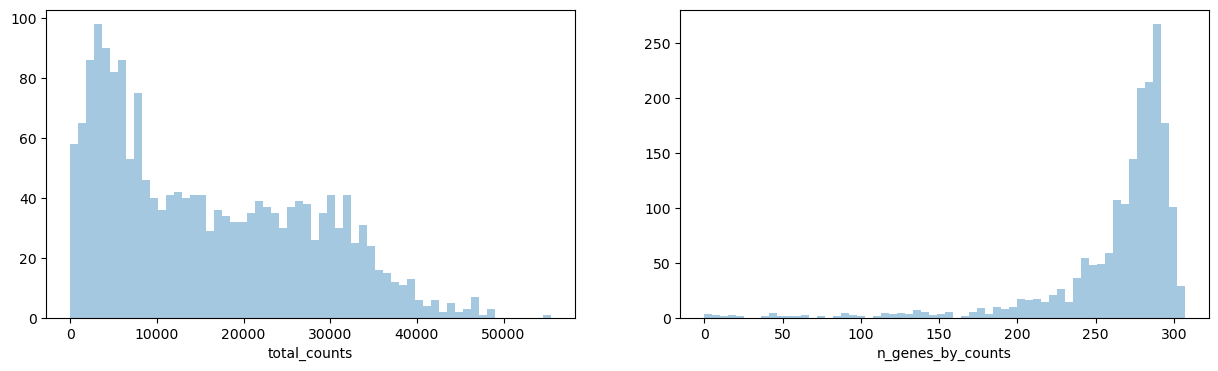

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sns.distplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
# sns.distplot(adata.obs["total_counts"][adata.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
sns.distplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])
# sns.distplot(adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])

In [8]:
# sc.pp.filter_cells(adata, min_counts=5000)
# sc.pp.filter_cells(adata, max_counts=35000)
sc.pp.filter_cells(adata, min_genes=30)
# adata = adata[adata.obs["pct_counts_mt"] < 20]
# print(f"#cells after MT filter: {adata.n_obs}")
sc.pp.filter_genes(adata, min_cells=10)

In [9]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

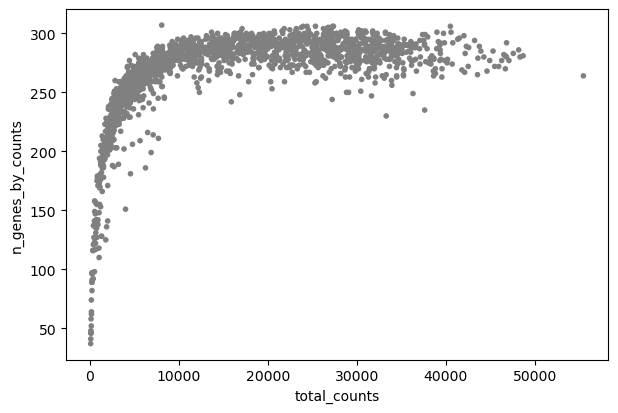

In [10]:
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [11]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 0.6, key_added="clusters")

/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-03-05 15:59:06.980932: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


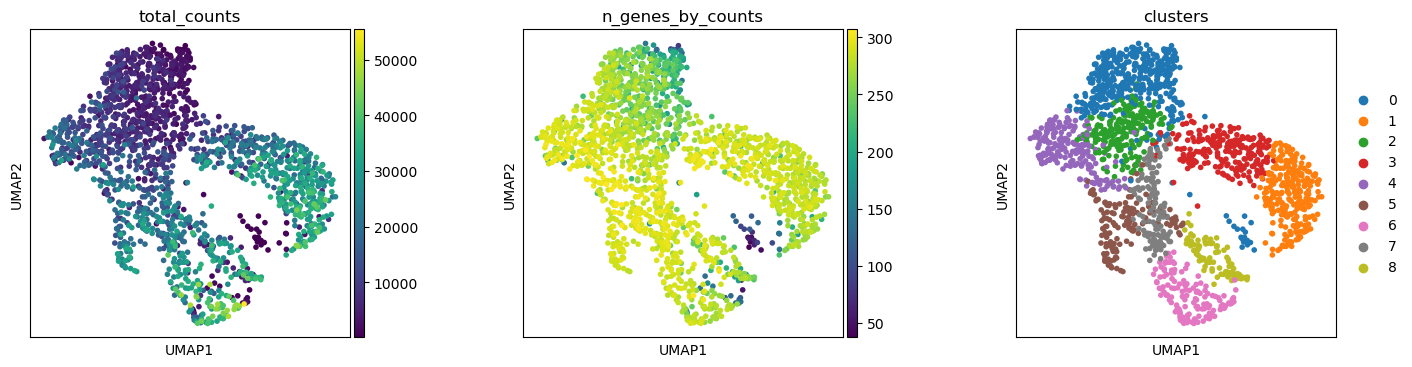

In [12]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

categories: 0, 1, 2, etc.
var_group_labels: 0, 1, 2, etc.


/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:2414: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


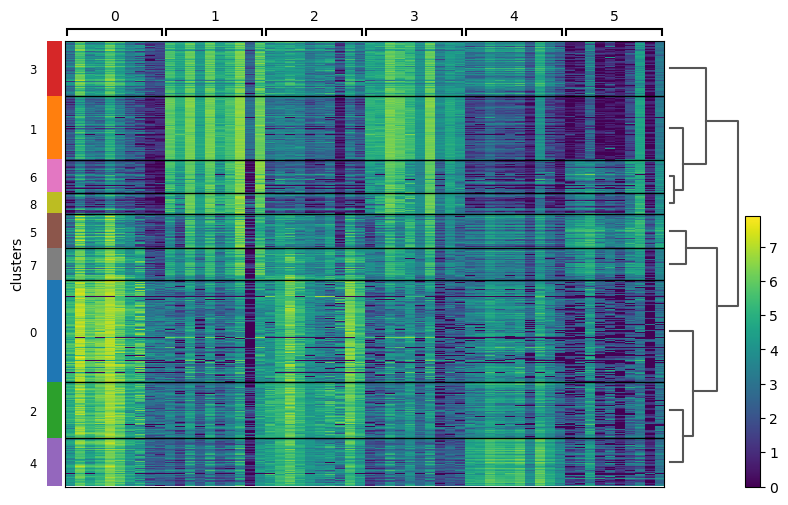

In [13]:
sc.tl.dendrogram(adata, groupby='clusters')
sc.tl.rank_genes_groups(adata, "clusters", method="t-test")
sc.pl.rank_genes_groups_heatmap(adata, groups="012345", n_genes=10, groupby="clusters")

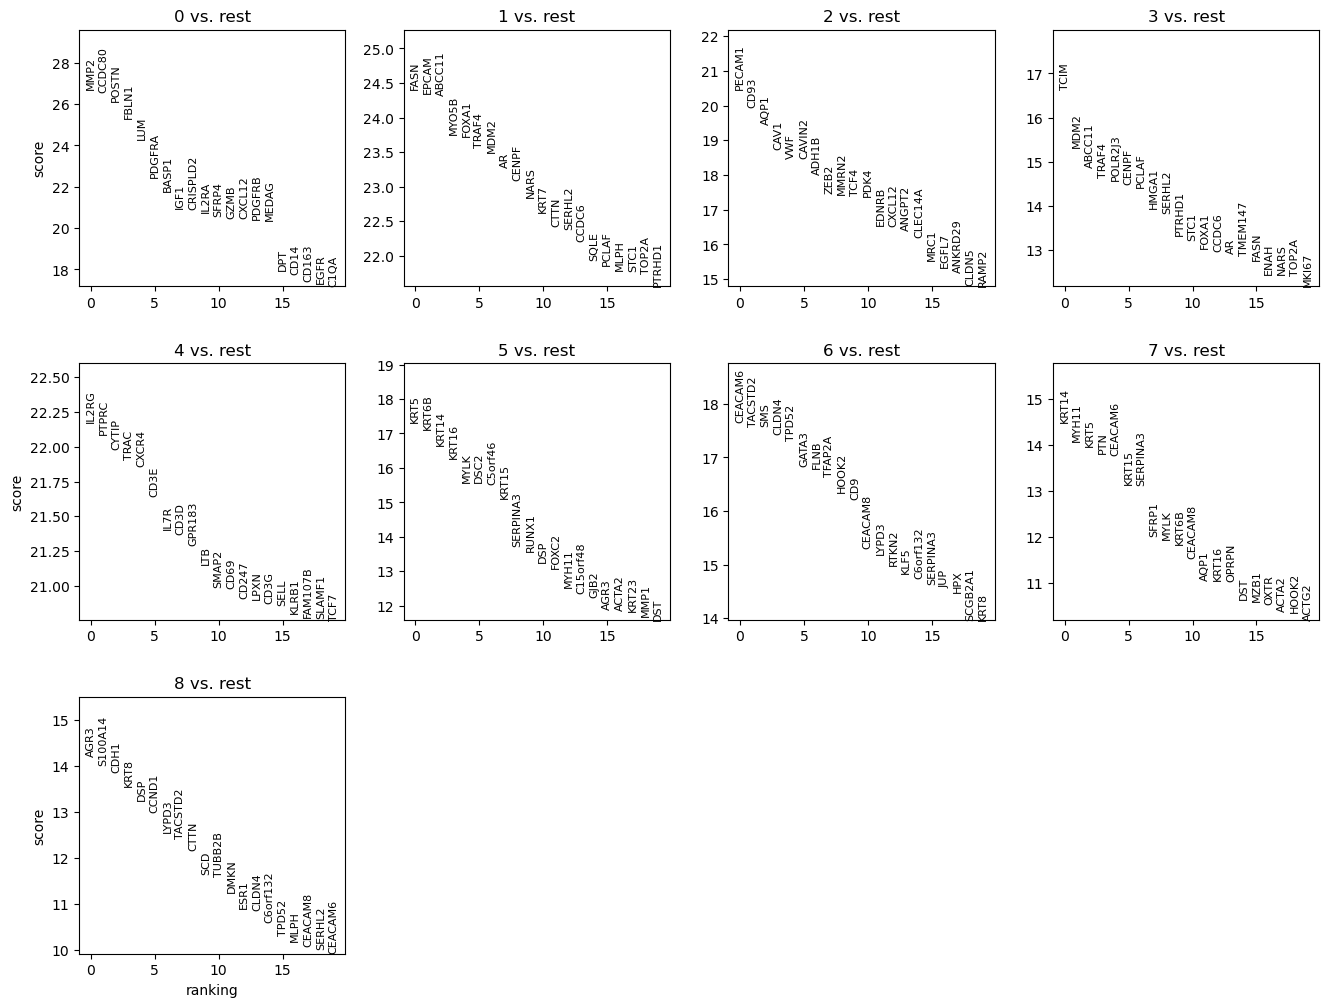

In [14]:
sc.tl.rank_genes_groups(adata, 'clusters', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [15]:
num = 2
marker_genes = list(set(np.array(pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(num)).reshape(-1)))
len(marker_genes)

18

/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


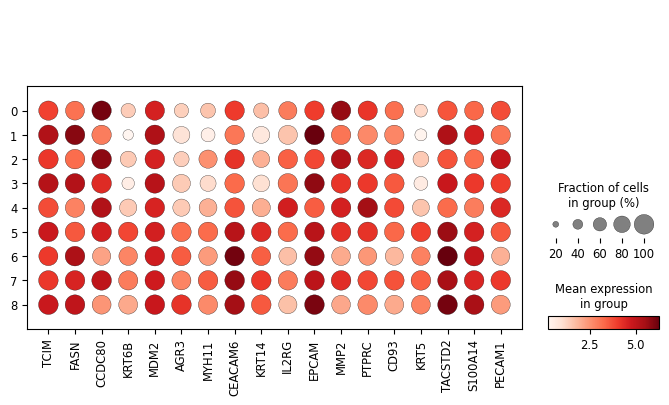

In [16]:
sc.pl.dotplot(adata, marker_genes, groupby='clusters');

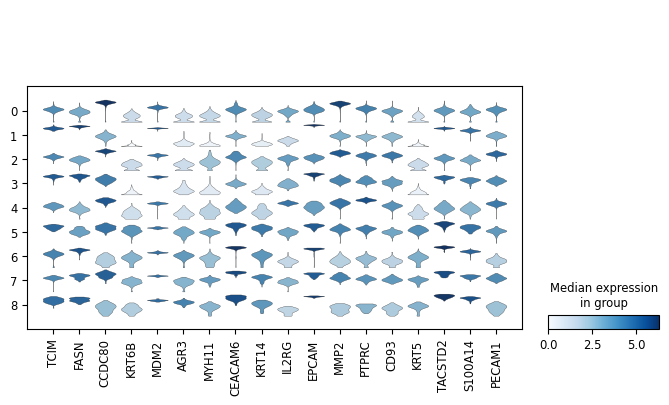

In [17]:
sc.pl.stacked_violin(adata, marker_genes, groupby='clusters', rotation=90);

In [18]:
adata.obs['clusters'].to_csv('predicted_with_membrane_pseudospot_clusters.csv')